In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Datasource = 'C:/Users/sushe/Documents/Kantar/Fraud Detection/data/datasets.csv'
RANDOM_STATE = 42
df = pd.read_csv(Datasource, parse_dates=["registration_timestamp"])
print("Shape:", df.shape)
print("Overall fraud rate: {:.2%}".format(df["is_fraud"].mean()))
df.head()

Shape: (50000, 13)
Overall fraud rate: 5.00%


,user_id,registration_timestamp,email_domain,age,gender,job_title,education_level,is_smoker,is_drinker,os,device_type,registration_duration_ms,is_fraud
0,e0adb1b0-7300-4f1c-a6c6-6d166cdfa2a6,2025-01-01 00:00:56.670990,hotmail.com,68,F,Mid-Level,High School,False,True,windows,desktop,14544.058189,False
1,8d135521-b7b3-42bf-a6c8-1a9fe078e571,2025-01-01 00:01:03.080025,gmail.com,57,F,Mid-Level,Bachelors,False,False,windows,desktop,11601.448980,False
2,82743fb3-4d4a-4ea4-a00e-92669db6bab0,2025-01-01 00:04:09.922874,hotmail.com,26,M,Mid-Level,Bachelors,False,False,ios,mobile,14883.372316,False
3,78248957-662c-464c-92c6-b318ba99f6bb,2025-01-01 00:04:49.539518,gmail.com,56,F,Mid-Level,Bachelors,False,False,windows,desktop,15336.277831,False
4,f1bbc4c9-92f5-498b-9482-1e9bd02d3d8e,2025-01-01 00:04:56.149444,gmail.com,33,M,Mid-Level,NaN,False,True,windows,desktop,15388.668264,False


In [2]:
print("Date range:", df["registration_timestamp"].min(), "->", df["registration_timestamp"].max())
print("\nMissing values:")
print(df.isna().sum()[df.isna().sum() > 0])

Date range: 2025-01-01 00:00:56.670990 -> 2025-01-30 23:59:45.957599

Missing values:
education_level    4895
dtype: int64


---
## Task 1 — Anomaly Detection

Here, I aggregated registrations over time. A coordinated fraud attack shows up as a
spike in **both** volume and fraud rate. I also found the day first, then zoom to
hourly resolution.

In [3]:
daily = df.set_index("registration_timestamp").resample("D")["is_fraud"].agg(
    registrations="size", frauds="sum")
daily["fraud_rate"] = daily["frauds"] / daily["registrations"]

print("Top 5 days by fraud rate:")
display(daily.sort_values("fraud_rate", ascending=False).head(5)
        .assign(fraud_rate=lambda d: (d["fraud_rate"]*100).round(1)))

Top 5 days by fraud rate:


,registrations,frauds,fraud_rate
registration_timestamp,,,
2025-01-11,2128,574,27.0
2025-01-12,1758,90,5.1
2025-01-03,1626,78,4.8
2025-01-22,1642,77,4.7
2025-01-25,1588,74,4.7


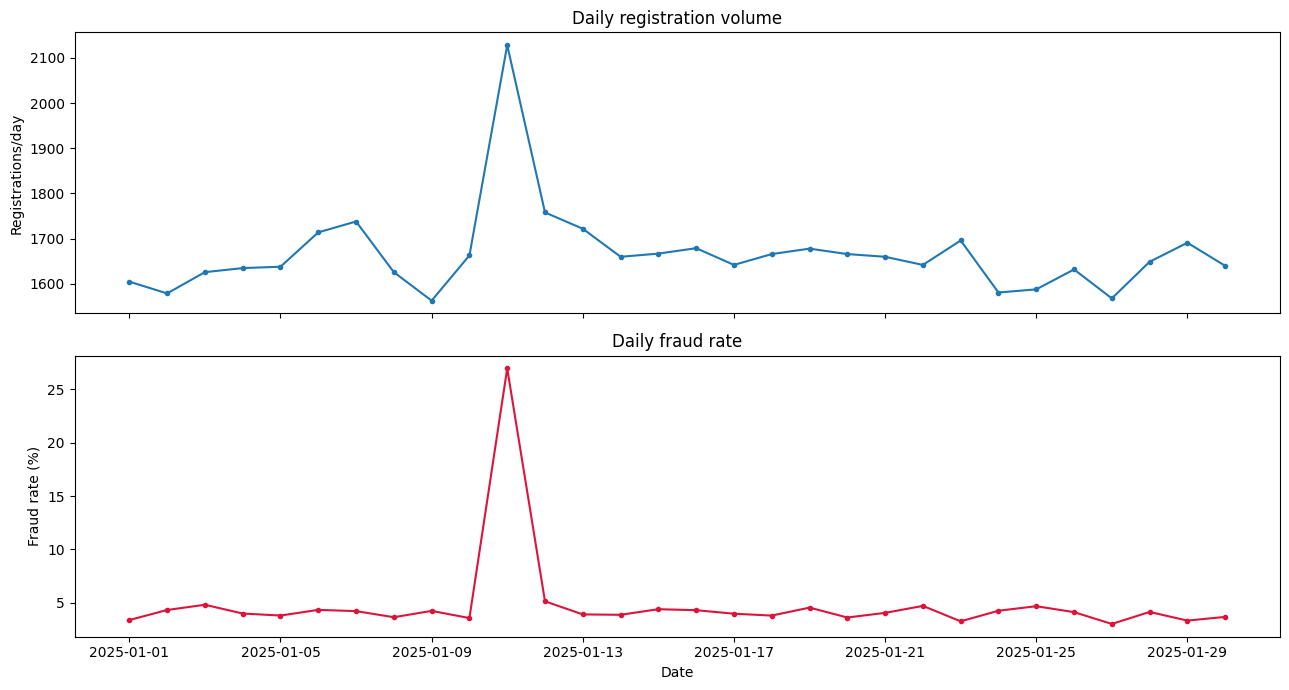

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax[0].plot(daily.index, daily["registrations"], marker="o", ms=3)
ax[0].set_ylabel("Registrations/day"); ax[0].set_title("Daily registration volume")
ax[1].plot(daily.index, daily["fraud_rate"]*100, marker="o", ms=3, color="crimson")
ax[1].set_ylabel("Fraud rate (%)"); ax[1].set_title("Daily fraud rate"); ax[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

**I see Jan 11 stands out dramatically. Upon Zooming to hourly resolution to pin the window.**

In [5]:
hourly = df.set_index("registration_timestamp").resample("h")["is_fraud"].agg(
    registrations="size", frauds="sum")
hourly["fraud_rate"] = hourly["frauds"] / hourly["registrations"]

def robust_z(s):
    med = s.median(); mad = (s - med).abs().median()
    scale = 1.4826*mad if mad > 0 else s.std(ddof=0)
    return (s - med) / (scale if scale else 1.0)

hourly["vol_z"]  = robust_z(hourly["registrations"])
hourly["rate_z"] = robust_z(hourly["fraud_rate"].fillna(0))
hourly["is_anomaly"] = (hourly["vol_z"] > 5) & (hourly["rate_z"] > 5)

anom = hourly[hourly["is_anomaly"]]
display(anom[["registrations","frauds","fraud_rate","vol_z","rate_z"]]
        .assign(fraud_rate=lambda d:(d["fraud_rate"]*100).round(1)))

start, end = anom.index.min(), anom.index.max() + pd.Timedelta(hours=1)
win = df[(df.registration_timestamp>=start)&(df.registration_timestamp<end)]
print(f"\nDETECTED ANOMALY WINDOW: {start} -> {end}")
print(f"Registrations: {len(win):,} | fraud rate: {win['is_fraud'].mean():.1%} "
      f"| share of all fraud: {win['is_fraud'].sum()/df['is_fraud'].sum():.1%}")

,registrations,frauds,fraud_rate,vol_z,rate_z
registration_timestamp,,,,,
2025-01-11 01:00:00,246,177,72.0,20.009893,29.460440
2025-01-11 02:00:00,250,172,68.8,20.459553,28.097307
2025-01-11 03:00:00,232,165,71.1,18.436081,29.101175



DETECTED ANOMALY WINDOW: 2025-01-11 01:00:00 -> 2025-01-11 04:00:00
Registrations: 728 | fraud rate: 70.6% | share of all fraud: 20.6%


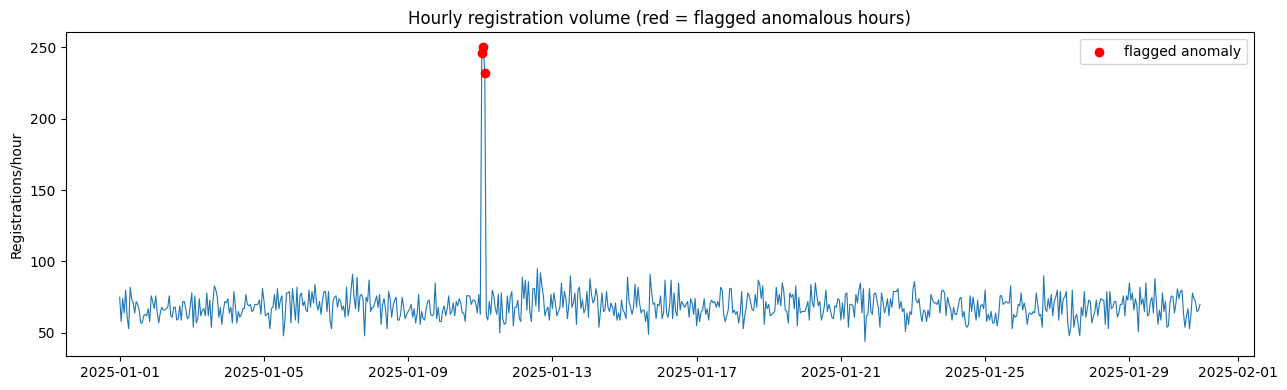

In [6]:
fig, ax = plt.subplots(figsize=(13,4))
ax.plot(hourly.index, hourly["registrations"], lw=0.8)
ax.scatter(anom.index, anom["registrations"], color="red", zorder=5, label="flagged anomaly")
ax.set_title("Hourly registration volume (red = flagged anomalous hours)")
ax.set_ylabel("Registrations/hour")
ax.legend()
plt.tight_layout()
plt.show()

### Task 1 findings

- **Anomaly window: `2025-01-11 01:00` → `2025-01-11 04:00`.**
- ~70% fraud rate vs ~4% baseline; ~3.5× the normal hourly volume; ~20% of all month's fraud in 3 hours.

### Detecting this *without labels*
1. **Volume control charts** (rolling median + k·MAD / EWMA / Poisson limits) — this attack is a ~20σ volume event.
2. **STL decomposition + residual outliers** — respects daily seasonality, fewer false alarms.
3. **Unsupervised models** (`IsolationForest`, `LOF`, autoencoder) — bot cohorts cluster tightly in feature space.
4. **Distribution-drift tests** (PSI / KL / KS) — detect sudden shifts in the registration population.
5. **Velocity rules** on shared attributes (email domain, device fingerprint, bursts within seconds).


---
## Task 2 — Fraud Classification

### 2.1 Feature engineering
Here, I extracted **generic** temporal/behavioural features and deliberately avoid the
absolute date (which would let the model memorise the Jan-11 attack and fail to
generalise).

In [7]:
def engineer_features(df):
    df = df.copy(); ts = df["registration_timestamp"]
    df["reg_hour"] = ts.dt.hour
    df["reg_dayofweek"] = ts.dt.dayofweek
    df["reg_is_night"] = ts.dt.hour.isin([0,1,2,3,4,5]).astype(int)
    df["email_is_freemail"] = df["email_domain"].isin(
        ["gmail.com","yahoo.com","hotmail.com","outlook.com"]).astype(int)
    df["reg_duration_s"] = df["registration_duration_ms"]/1000.0
    for c in ["is_smoker","is_drinker"]:
        df[c] = df[c].astype(str)
    return df

data = engineer_features(df)

NUMERIC = ["age","reg_duration_s","reg_hour","reg_dayofweek","reg_is_night","email_is_freemail"]
CATEG   = ["email_domain","gender","job_title","education_level","os","device_type","is_smoker","is_drinker"]

X = data[NUMERIC + CATEG]
y = data["is_fraud"].astype(int)
print("Features:", X.shape, "| positive rate:", round(y.mean(),4))

Features: (50000, 14) | positive rate: 0.05


**EDA: fraud rate by key categorical features confirms the signal.**

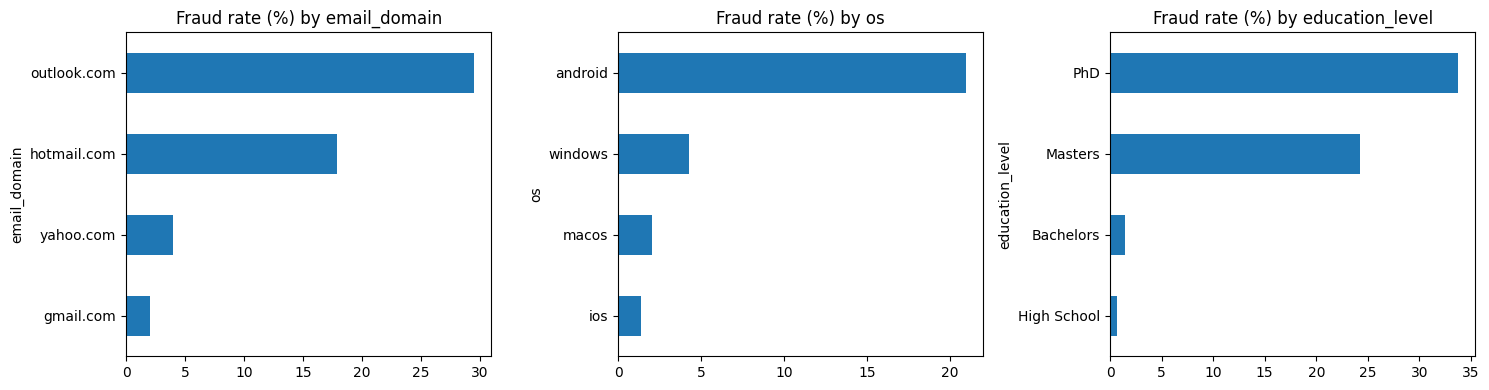

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ["email_domain","os","education_level"]):
    (df.groupby(col)["is_fraud"].mean()*100).sort_values().plot.barh(ax=ax)
    ax.set_title(f"Fraud rate (%) by {col}"); ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric = Pipeline([("impute", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler())])
categorical = Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="MISSING")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
preproc = ColumnTransformer([("num", numeric, NUMERIC), ("cat", categorical, CATEG)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)
print("Train:", X_train.shape, "Test:", X_test.shape)
spw = (y_train==0).sum()/(y_train==1).sum()
print("scale_pos_weight:", round(spw,2))

Train: (37500, 14) Test: (12500, 14)
scale_pos_weight: 19.0


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, confusion_matrix,
                             RocCurveDisplay, PrecisionRecallDisplay)

from xgboost import XGBClassifier

models = {
  "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
  "RandomForest": RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                         class_weight="balanced", n_jobs=-1, random_state=42),
}
models["XGBoost"] = XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.08,subsample=0.9, colsample_bytree=0.9, scale_pos_weight=spw,eval_metric="aucpr", random_state=42, n_jobs=-1, tree_method="hist")

results, fitted = [], {}
for name, model in models.items():
    pipe = Pipeline([("prep", preproc), ("clf", model)]).fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:,1]; pred = (proba>=0.5).astype(int)
    roc, pr = roc_auc_score(y_test, proba), average_precision_score(y_test, proba)
    results.append({"model":name,"roc_auc":roc,"pr_auc":pr,"proba":proba})
    fitted[name] = pipe
    print(f"\n=== {name} ===  ROC-AUC={roc:.4f}  PR-AUC={pr:.4f}")
    print(classification_report(y_test, pred, digits=3))
    print("Confusion matrix:\n", confusion_matrix(y_test, pred))


=== LogisticRegression ===  ROC-AUC=0.9680  PR-AUC=0.7725
              precision    recall  f1-score   support

           0      0.994     0.921     0.956     11875
           1      0.371     0.888     0.524       625

    accuracy                          0.919     12500
   macro avg      0.683     0.904     0.740     12500
weighted avg      0.963     0.919     0.934     12500

Confusion matrix:
 [[10936   939]
 [   70   555]]

=== RandomForest ===  ROC-AUC=0.9597  PR-AUC=0.7623
              precision    recall  f1-score   support

           0      0.982     0.987     0.985     11875
           1      0.725     0.666     0.694       625

    accuracy                          0.971     12500
   macro avg      0.854     0.826     0.839     12500
weighted avg      0.970     0.971     0.970     12500

Confusion matrix:
 [[11717   158]
 [  209   416]]

=== XGBoost ===  ROC-AUC=0.9613  PR-AUC=0.7537
              precision    recall  f1-score   support

           0      0.988     0.9

In [11]:
comp = pd.DataFrame([{k:v for k,v in r.items() if k!="proba"} for r in results])
display(comp.sort_values("pr_auc", ascending=False).reset_index(drop=True))

best = max(results, key=lambda r: r["pr_auc"]); best_pipe = fitted[best["model"]]
print("Best model by PR-AUC:", best["model"])

,model,roc_auc,pr_auc
0,LogisticRegression,0.968028,0.772488
1,RandomForest,0.959729,0.762286
2,XGBoost,0.961282,0.753667


Best model by PR-AUC: LogisticRegression


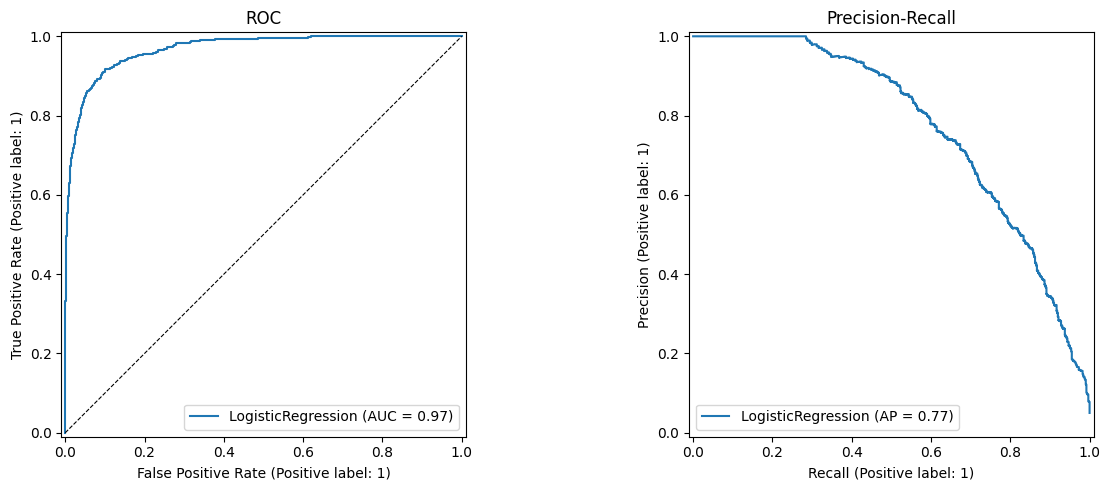

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13,5))
RocCurveDisplay.from_predictions(y_test, best["proba"], ax=ax[0], name=best["model"])
ax[0].plot([0,1],[0,1],"k--",lw=.8); ax[0].set_title("ROC")
PrecisionRecallDisplay.from_predictions(y_test, best["proba"], ax=ax[1], name=best["model"])
ax[1].set_title("Precision-Recall"); plt.tight_layout(); plt.show()

**Feature Importance**

In [13]:
clf = best_pipe.named_steps["clf"]
if hasattr(clf, "feature_importances_"):
    names = best_pipe.named_steps["prep"].get_feature_names_out()
    imp = pd.Series(clf.feature_importances_, index=names).sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(9,6)); imp[::-1].plot.barh(ax=ax)
    ax.set_title(f"Top 15 features — {best['model']}"); plt.tight_layout(); plt.show()
    display(imp.head(10).round(4))
else:
    coefs = pd.Series(clf.coef_[0],
        index=best_pipe.named_steps["prep"].get_feature_names_out())
    display(coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(10).round(3))

cat__education_level_PhD            2.389
cat__education_level_High School   -1.974
cat__education_level_Masters        1.878
cat__job_title_Mid-Level           -1.728
cat__job_title_CEO                  1.633
cat__job_title_Director             1.578
cat__os_android                     1.516
cat__email_domain_gmail.com        -1.464
cat__education_level_Bachelors     -1.347
cat__job_title_Junior              -1.324
dtype: float64

---
## Summary & Further Steps

**Task 1:** I found a clear scripted-attack window on **2025-01-11, 01:00–04:00** (~70% fraud,
~20× normal fraud share). Label-free detection via volume control charts, STL residuals,
unsupervised outlier models, and drift tests.

**Task 2:** Strong classifiers (ROC-AUC ≈ 0.96–0.97). Top drivers are education level
(PhD/Masters), email domain, OS (Android), and senior job titles — consistent with the EDA.
PR-AUC is the right headline metric given 19:1 imbalance.

**Further steps:** time-based splits to prove generalisation beyond the Jan-11 cohort;
cost-based threshold tuning + probability calibration; richer velocity/fingerprint features;
unsupervised anomaly score as a model feature; SHAP explainability; drift monitoring and
scheduled retraining; cross-validated hyperparameter search.
